<a href="https://colab.research.google.com/github/raki-rankawat/stm32-thesis/blob/main/MobileNetV2_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [52]:
# =====================================================
# Imports
# =====================================================

import os
import time
import tarfile
import random
import shutil
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from google.colab import drive

In [53]:
# =====================================================
# Mount Google Drive
# =====================================================

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [54]:
# =====================================================
# Device Setup
# =====================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(41)
random.seed(41)

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

print("Device:", device)

Device: cuda


In [55]:
# =====================================================
# Dataset Configuration
# =====================================================

VWW_URL = "https://www.silabs.com/public/files/github/machine_learning/benchmarks/datasets/vw_coco2014_96.tar.gz"

BASE_DIR = Path("/content/vww_work")
ARCHIVE_PATH = BASE_DIR / "vw_coco2014_96.tar.gz"
EXTRACT_DIR = BASE_DIR / "extracted"
SUBSET_DIR = BASE_DIR / "vww_10k"

N_PER_CLASS = 5000
VAL_RATIO = 0.20

In [56]:
# =====================================================
# Download VWW Dataset
# =====================================================

def download_vww():

    BASE_DIR.mkdir(parents=True, exist_ok=True)

    if ARCHIVE_PATH.exists() and ARCHIVE_PATH.stat().st_size > 0:
        print("✅ VWW archive already downloaded")
        return

    print("⬇️ Downloading VWW archive...")
    urlretrieve(VWW_URL, ARCHIVE_PATH)
    print("✅ Download complete:", ARCHIVE_PATH)

In [57]:
# =====================================================
# Extract Dataset
# =====================================================

def extract_vww():

    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

    if any(EXTRACT_DIR.iterdir()):
        print("✅ VWW already extracted")
        return

    print("📦 Extracting VWW archive...")

    with tarfile.open(ARCHIVE_PATH, "r:gz") as tar:
        tar.extractall(EXTRACT_DIR)

    print("✅ Extraction complete:", EXTRACT_DIR)

In [58]:
# =====================================================
# Locate Dataset Root
# =====================================================

def find_vww_root():

    for p in EXTRACT_DIR.rglob("person"):
        if p.is_dir() and (p.parent / "non_person").is_dir():
            return p.parent

    raise RuntimeError("❌ Could not find dataset directories")

In [59]:
# =====================================================
# Image Listing Helper
# =====================================================

def list_images(folder):

    exts = {".jpg", ".jpeg", ".png"}

    return [
        p for p in folder.rglob("*")
        if p.is_file() and p.suffix.lower() in exts
    ]

In [60]:
# =====================================================
# Create 10K Subset
# =====================================================

def make_vww_subset(src_root):

    if (SUBSET_DIR / "train" / "person").exists():
        print("✅ VWW subset already exists:", SUBSET_DIR)
        return

    for split in ["train", "val"]:
        for c in ["person", "non_person"]:
            (SUBSET_DIR / split / c).mkdir(parents=True, exist_ok=True)

    person_imgs = list_images(src_root / "person")
    nonperson_imgs = list_images(src_root / "non_person")

    if len(person_imgs) < N_PER_CLASS or len(nonperson_imgs) < N_PER_CLASS:
        raise ValueError("❌ Not enough images in dataset")

    random.shuffle(person_imgs)
    random.shuffle(nonperson_imgs)

    person_sel = person_imgs[:N_PER_CLASS]
    nonperson_sel = nonperson_imgs[:N_PER_CLASS]

    def split_list(lst):

        n_val = int(len(lst) * VAL_RATIO)
        return lst[n_val:], lst[:n_val]

    p_train, p_val = split_list(person_sel)
    n_train, n_val = split_list(nonperson_sel)

    def copy_files(files, dst):

        for f in files:
            target = dst / f.name

            if target.exists():
                target = dst / f"{f.parent.name}_{f.name}"

            shutil.copy2(f, target)

    print("🧩 Creating VWW subset...")

    copy_files(p_train, SUBSET_DIR / "train" / "person")
    copy_files(p_val,   SUBSET_DIR / "val"   / "person")
    copy_files(n_train, SUBSET_DIR / "train" / "non_person")
    copy_files(n_val,   SUBSET_DIR / "val"   / "non_person")

    print("✅ Subset created:", SUBSET_DIR)

In [61]:
# =====================================================
# Prepare Dataset
# =====================================================

download_vww()
extract_vww()

vww_root = find_vww_root()
print("Dataset root:", vww_root)

make_vww_subset(vww_root)

✅ VWW archive already downloaded
✅ VWW already extracted
Dataset root: /content/vww_work/extracted/vw_coco2014_96
✅ VWW subset already exists: /content/vww_work/vww_10k


In [62]:
# =====================================================
# Data Loaders
# =====================================================

BATCH_SIZE = 64
IMG_SIZE = 96


train_transform = transforms.Compose([

    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.5, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),

    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3
    ),

    transforms.RandomGrayscale(p=0.1),

    transforms.ToTensor(),

    transforms.Normalize(
        (0.485, 0.456, 0.406),
        (0.229, 0.224, 0.225)
    )
])


test_transform = transforms.Compose([

    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),

    transforms.Normalize(
        (0.485, 0.456, 0.406),
        (0.229, 0.224, 0.225)
    )
])


train_data = datasets.ImageFolder(
    root=str(SUBSET_DIR / "train"),
    transform=train_transform
)

test_data = datasets.ImageFolder(
    root=str(SUBSET_DIR / "val"),
    transform=test_transform
)


train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Class mapping:", train_data.class_to_idx)

Class mapping: {'non_person': 0, 'person': 1}


In [63]:
# =====================================================
# MobileNetV2 Block
# =====================================================

class InvertedResidual(nn.Module):

    def __init__(self, in_channels, out_channels, stride, expand_ratio):
        super().__init__()

        hidden_dim = in_channels * expand_ratio
        self.use_residual = stride == 1 and in_channels == out_channels

        self.block = nn.Sequential(

            nn.Conv2d(in_channels, hidden_dim, 1, bias=False),
            nn.BatchNorm2d(hidden_dim),
            nn.ReLU6(inplace=True),

            nn.Conv2d(
                hidden_dim,
                hidden_dim,
                3,
                stride=stride,
                padding=1,
                groups=hidden_dim,
                bias=False
            ),

            nn.BatchNorm2d(hidden_dim),
            nn.ReLU6(inplace=True),

            nn.Conv2d(hidden_dim, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
        )

    def forward(self, x):

        if self.use_residual:
            return x + self.block(x)

        return self.block(x)

In [64]:
# =====================================================
# MobileNetV2 Model
# =====================================================

class VWW_MobileNetV2(nn.Module):

    def __init__(self):
        super().__init__()

        self.initial = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU6(inplace=True)
        )

        self.features = nn.Sequential(
            InvertedResidual(32, 16, 1, 1),

            InvertedResidual(16, 24, 2, 6),
            InvertedResidual(24, 24, 1, 6),

            InvertedResidual(24, 32, 2, 6),
            InvertedResidual(32, 32, 1, 6),

            InvertedResidual(32, 64, 2, 6),
            InvertedResidual(64, 64, 1, 6),
        )

        self.final_conv = nn.Sequential(
            nn.Conv2d(64, 512, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU6(inplace=True)
        )

        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(512, 2)
        self._initialize_weights()

    def forward(self, x):
        x = self.initial(x)
        x = self.features(x)
        x = self.final_conv(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

    def _initialize_weights(self):

        for m in self.modules():

            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out')

            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.zeros_(m.bias)

In [65]:
# =====================================================
# Model Initialization
# =====================================================

model = VWW_MobileNetV2().to(device)

In [66]:
# =====================================================
# Loss, Optimizer, Scheduler
# =====================================================

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=50
)

In [67]:
# =====================================================
# Training Function
# =====================================================

def train(model, loader):

    model.train()

    correct = 0
    total = 0
    running_loss = 0

    for X, y in loader:
        X = X.to(device)
        y = y.to(device)

        outputs = model(X)
        loss = criterion(outputs, y)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        batch_size = y.size(0)
        running_loss += loss.item() * batch_size

        preds = outputs.argmax(1)
        correct += (preds == y).sum().item()
        total += batch_size

    return running_loss / total, correct / total

In [68]:
# =====================================================
# Testing Function
# =====================================================

def test(model, loader):

    model.eval()

    correct = 0
    total = 0
    running_loss = 0

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            y = y.to(device)

            outputs = model(X)
            loss = criterion(outputs, y)

            batch_size = y.size(0)
            running_loss += loss.item() * batch_size
            preds = outputs.argmax(1)

            correct += (preds == y).sum().item()
            total += batch_size

    return running_loss / total, correct / total

In [69]:
# =====================================================
# Training Loop
# =====================================================

EPOCHS = 50

train_losses = []
train_accs = []

test_losses = []
test_accs = []

best_acc = 0
patience = 8
patience_counter = 0

best_path = "/content/drive/My Drive/Colab Notebooks/vww_mobilenetv2_model.pth"

start_time = time.time()

for epoch in range(1, EPOCHS + 1):

    train_loss, train_acc = train(model, train_loader)
    test_loss, test_acc = test(model, test_loader)

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    test_losses.append(test_loss)
    test_accs.append(test_acc)

    scheduler.step()

    print(
        f"Epoch {epoch}/{EPOCHS} | "
        f"LR {scheduler.get_last_lr()[0]:.6f} | "
        f"Train Loss {train_loss:.4f} | Train Acc {train_acc*100:.2f}% | "
        f"Val Loss {test_loss:.4f} | Val Acc {test_acc*100:.2f}%"
    )

    if test_acc > best_acc:
        best_acc = test_acc
        patience_counter = 0

        torch.save(model.state_dict(), best_path)
        print("✅ Model saved")
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("🛑 Early stopping triggered")
        break

print("Training time:", (time.time() - start_time) / 60, "minutes")
print("Best accuracy:", best_acc * 100)

Epoch 1/50 | LR 0.000999 | Train Loss 0.6820 | Train Acc 57.24% | Val Loss 0.6626 | Val Acc 62.20%
✅ Model saved
Epoch 2/50 | LR 0.000996 | Train Loss 0.6555 | Train Acc 62.50% | Val Loss 0.6791 | Val Acc 62.60%
✅ Model saved
Epoch 3/50 | LR 0.000991 | Train Loss 0.6377 | Train Acc 65.19% | Val Loss 0.6301 | Val Acc 66.05%
✅ Model saved
Epoch 4/50 | LR 0.000984 | Train Loss 0.6278 | Train Acc 66.45% | Val Loss 0.6578 | Val Acc 62.45%
Epoch 5/50 | LR 0.000976 | Train Loss 0.6157 | Train Acc 68.29% | Val Loss 0.6086 | Val Acc 68.90%
✅ Model saved
Epoch 6/50 | LR 0.000965 | Train Loss 0.6083 | Train Acc 68.55% | Val Loss 0.5867 | Val Acc 71.05%
✅ Model saved
Epoch 7/50 | LR 0.000952 | Train Loss 0.6057 | Train Acc 68.94% | Val Loss 0.5907 | Val Acc 72.05%
✅ Model saved
Epoch 8/50 | LR 0.000938 | Train Loss 0.5963 | Train Acc 70.39% | Val Loss 0.5799 | Val Acc 72.80%
✅ Model saved
Epoch 9/50 | LR 0.000922 | Train Loss 0.5952 | Train Acc 71.23% | Val Loss 0.5563 | Val Acc 74.10%
✅ Model sav

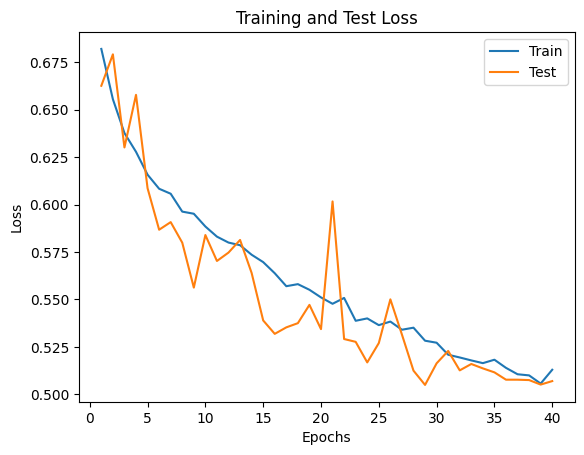

In [70]:
# =====================================================
# Loss Plot
# =====================================================

plt.figure()
plt.plot(range(1, len(train_losses) + 1), train_losses)
plt.plot(range(1, len(test_losses) + 1), test_losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Test Loss")
plt.legend(["Train", "Test"])
plt.show()

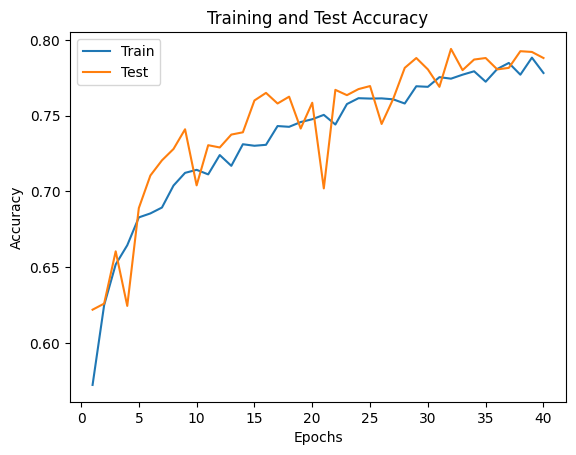

In [71]:
# =====================================================
# Accuracy Plot
# =====================================================

plt.figure()
plt.plot(range(1, len(train_accs) + 1), train_accs)
plt.plot(range(1, len(test_accs) + 1), test_accs)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Test Accuracy")
plt.legend(["Train", "Test"])
plt.show()

In [72]:
# =====================================================
# Denormalize Images
# =====================================================

def denormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return img * std + mean

In [73]:
# =====================================================
# Show Specific CIFAR Test Images (One Row)
# =====================================================

classes = train_data.classes

def show_specific_images(indices):

    model.eval()
    num_images = len(indices)

    plt.figure(figsize=(3 * num_images, 3))

    for i, idx in enumerate(indices):
        image, label = test_data[idx]

        # Keep original normalized tensor for inference
        input_tensor = image.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(input_tensor)
            probabilities = F.softmax(output, dim=1)
            confidence, predicted = torch.max(probabilities, 1)

        # Denormalize only for display
        image_display = denormalize(image).clamp(0, 1)

        plt.subplot(1, num_images, i + 1)
        plt.imshow(image_display.permute(1, 2, 0).cpu())

        correct = predicted.item() == label
        color = "green" if correct else "red"

        plt.title(
            f"P: {classes[predicted.item()]}\n"
            f"T: {classes[label]}\n"
            f"{confidence.item()*100:.1f}%",
            color=color
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

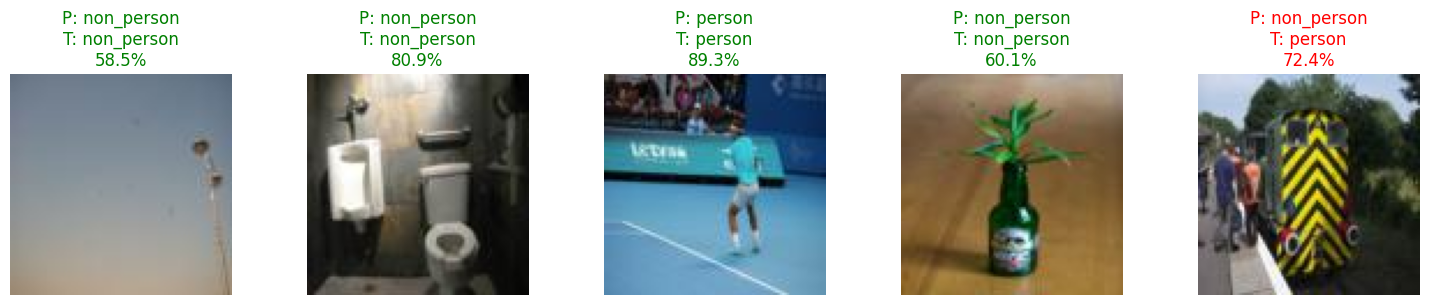

In [74]:
show_specific_images([500, 303, 1011, 999, 1001])

In [75]:
# =====================================================
# Show Random Test Predictions (One Row)
# =====================================================

classes = train_data.classes

def show_random_predictions(num_images=5):

    model.eval()
    indices = random.sample(range(len(test_data)), num_images)

    plt.figure(figsize=(3 * num_images, 3))

    for i, idx in enumerate(indices):
        image, label = test_data[idx]

        # Keep normalized image for inference
        input_tensor = image.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(input_tensor)
            probabilities = F.softmax(output, dim=1)
            confidence, predicted = torch.max(probabilities, 1)

        # Denormalize only for visualization
        image_display = denormalize(image).clamp(0, 1)

        plt.subplot(1, num_images, i + 1)
        plt.imshow(image_display.permute(1, 2, 0).cpu())

        correct = predicted.item() == label
        color = "green" if correct else "red"

        plt.title(
            f"P: {classes[predicted.item()]}\n"
            f"T: {classes[label]}\n"
            f"{confidence.item()*100:.1f}%",
            color=color
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

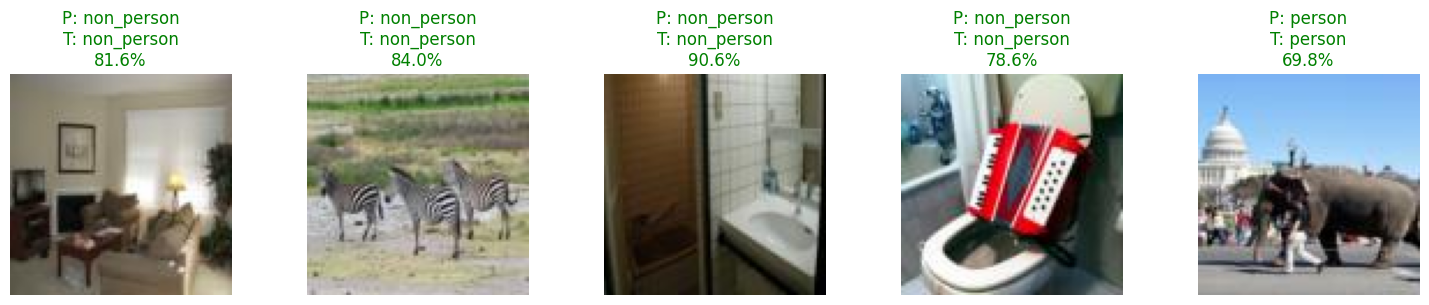

In [76]:
show_random_predictions(5)